In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")

In [2]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root="dataset", name="Cora")

data = dataset[0]

print(f"Dataset : {dataset}")
print(f"-------------------")
print(f"Number of graphs : {len(dataset)}")
print(f"Number of nodes : {dataset.x.shape[0]}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")

print(f"\nGraph:")
print("----------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

Dataset : Cora()
-------------------
Number of graphs : 1
Number of nodes : 2708
Number of features: 1433
Number of classes: 7

Graph:
----------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


In [9]:
# Facebook Pasge dataset ==> Error로 이 실습에서 Facebook 데이터 관련 실습은 제외
from torch_geometric.datasets import FacebookPagePage

# dataset = FacebookPagePage(root="dataset") ==> HTTP Error 404 발생

dataset = FacebookPagePage(root="dataset")
data = dataset[0]

print(f"Dataset : {Dataset}")
print("----------------------")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of nodes: {data.x.shape[0]}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")

print(f"\nGraph:")
print("----------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

# create masks
data.train_mask = range(18000)
data.val_mask = range(18001,20000)
data.test_mask = range(20001, 22470)

HTTPError: HTTP Error 404: Not Found

In [3]:
# Cara dataset 을 DataFrame으로 변환
import pandas as pd

dataset = Planetoid(root="dataset", name="Cora")
data = dataset[0]

df_x = pd.DataFrame(data.x.numpy())
df_x["label"] = pd.DataFrame(data.y)
df_x

,0,1,2,3,4,5,6,7,8,9,...,1424,1425,1426,1427,1428,1429,1430,1431,1432,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2704,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [4]:
# Torch MLP
# Pytorch MLP 모델을 구성하여 Classification 학습을 진행
import torch
# 랜덤시드 고정을 통해 동일한 결과가 나오도록 설정
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F

def accuracy(y_pred, y_true):
    return torch.sum(y_pred == y_true) / len(y_true)

class MLP(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs):
        # 분류 문제에서는 CrossEntropyLoss loss function 사용
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),lr=0.01, weight_decay=5e-4)
        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if (epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f"Epoch {epochs:>3} | Train Loss: {loss:.3f} | Train Acc:" f"{acc*100:>5.2f}% | Val Loss: {val_loss:.2f} |" f"Val Acc: {val_acc*100:.2f}%")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = accuracy(out.argmax(dim=1)[data.test_mask],data.y[data.test_mask])
        return acc

# Create MLP model
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f"\nMLP test accuracy: {acc*100:.2f}%")


MLP(
  (linear1): Linear(in_features=1433, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=7, bias=True)
)
Epoch 100 | Train Loss: 1.959 | Train Acc:14.29% | Val Loss: 2.00 |Val Acc: 12.40%
Epoch 100 | Train Loss: 0.110 | Train Acc:100.00% | Val Loss: 1.46 |Val Acc: 49.40%
Epoch 100 | Train Loss: 0.014 | Train Acc:100.00% | Val Loss: 1.44 |Val Acc: 51.00%
Epoch 100 | Train Loss: 0.008 | Train Acc:100.00% | Val Loss: 1.40 |Val Acc: 53.80%
Epoch 100 | Train Loss: 0.008 | Train Acc:100.00% | Val Loss: 1.37 |Val Acc: 55.40%
Epoch 100 | Train Loss: 0.009 | Train Acc:100.00% | Val Loss: 1.34 |Val Acc: 54.60%

MLP test accuracy: 53.40%


In [5]:
# VanillaGNN
class VanillaGNNLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x

In [7]:
from torch_geometric.utils import to_dense_adj

adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.]])

In [9]:
# visualization function
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())
    
    plt.figure(figsize=(8,8))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=False)
  )
)
Epoch   0 | Train Loss: 2.381 | Train Acc: 7.86% | Val Loss: 2.16 |Val Acc: 18.80%
Epoch  20 | Train Loss: 0.100 | Train Acc:99.29% | Val Loss: 1.52 |Val Acc: 74.80%
Epoch  40 | Train Loss: 0.007 | Train Acc:100.00% | Val Loss: 2.29 |Val Acc: 74.00%
Epoch  60 | Train Loss: 0.002 | Train Acc:100.00% | Val Loss: 2.50 |Val Acc: 74.20%
Epoch  80 | Train Loss: 0.002 | Train Acc:100.00% | Val Loss: 2.50 |Val Acc: 74.00%
Epoch 100 | Train Loss: 0.002 | Train Acc:100.00% | Val Loss: 2.46 |Val Acc: 74.20%


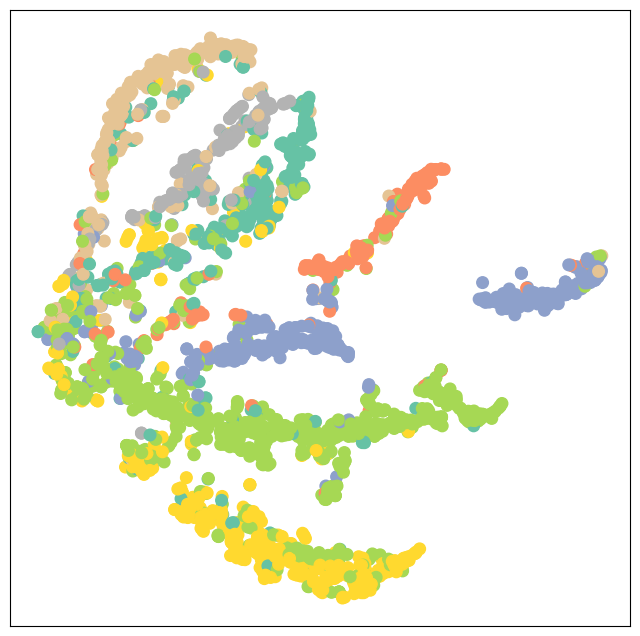


GNN test accuracy: 75.10%


In [11]:
class VanillaGNN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = VanillaGNNLayer(dim_in, dim_h)
        self.gnn2 = VanillaGNNLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)
        self.train()

        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:" f"{acc*100:>5.2f}% | Val Loss: {val_loss:.2f} |" f"Val Acc: {val_acc*100:.2f}%")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        visualize(out, color=data.y)
        return acc

gnn = VanillaGNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)

gnn.fit(data, epochs=100)

acc = gnn.test(data)
print(f"\nGNN test accuracy: {acc*100:.2f}%")



## GCN

In [4]:
# node regression을 WikipediaNetwork dataset을 활용하여 작업 수행
from torch_geometric.datasets import WikipediaNetwork
import torch_geometric.transforms as T

dataset = WikipediaNetwork(
    root="dataset",
    name = "Chameleon",
    transform = T.RandomNodeSplit(num_val=200, num_test=500)
)
data = dataset[0]

#
print(f"Dataset: {dataset}")
print("------------------")
print(f"Number of graphs : {len(dataset)}")
print(f"Number of nodes: {data.x.shape[0]}")
print(f"Number of unique features: {dataset.num_features}")
print(f"Number of classes : {dataset.num_classes}")

print(f"\nGraph")
print(f"--------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

Processing...


Dataset: WikipediaNetwork()
------------------
Number of graphs : 1
Number of nodes: 2277
Number of unique features: 2325
Number of classes : 5

Graph
--------
Edges are directed: True
Graph has isolated nodes: False
Graph has loops: True


Done!


In [5]:
# WikipediaNetwork dataset을 활용하여 Node Regreession 문제를 위한 준비단계
# Chameleon graph를 로드하고 , 학습, 검증, 데스트데이터를 생성한 후 그래프의 기본적인 속성을 확인9
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

# urlopen : 데이터 다운로드
# BytesIO : 메모리에서 처리
# ZipFile : 압축 해제
url = "https://snap.stanford.edu/data/wikipedia.zip"
with urlopen(url) as zurl:
    with ZipFile(BytesIO(zurl.read())) as zfile:
        zfile.extractall(".")

In [9]:
import pandas as pd
import numpy as np
import torch

df = pd.read_csv("wikipedia/chameleon/musae_chameleon_target.csv")
# Log 변환을 통해 데이터의 스케일 조정하여 모델이 보다 안정적으로 학습하도록 지원
values = np.log10(df["target"])
# data.y 에 valeus 값을 할당하여 graph data의 label을 설정
data.y = torch.tensor(values)
data.y

tensor([2.2330, 3.9079, 3.9329,  ..., 1.9956, 4.3598, 2.4409],
       dtype=torch.float64)

<BarContainer object of 63 artists>

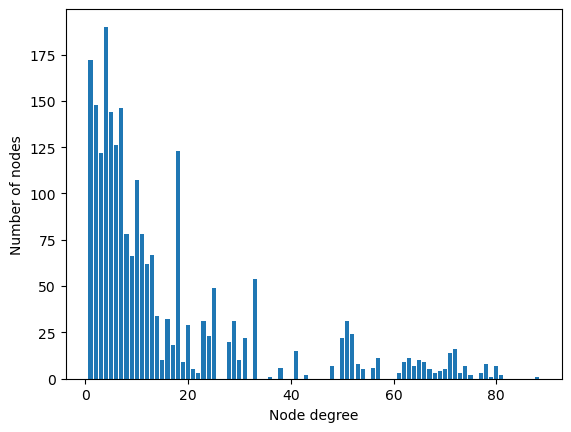

In [19]:
# 각 노드의 Degree를 분석하고 시각화
# GNN 에서 노드 차수는 모델 성능에 영향을 미칠 수 있는 중요한 요소
from torch_geometric.utils import degree
from collections import Counter
import matplotlib.pyplot as plt

# Get list of degree for each node
degrees = degree(data.edge_index[0]).numpy()

# Count the number of nodes for each degree
numbers = Counter(degrees)

# Bar plot
fig, ax = plt.subplots()
ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
plt.bar(numbers.keys(), numbers.values())

/tmp/ipykernel_34894/1175666606.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(df["target"], fit=norm)


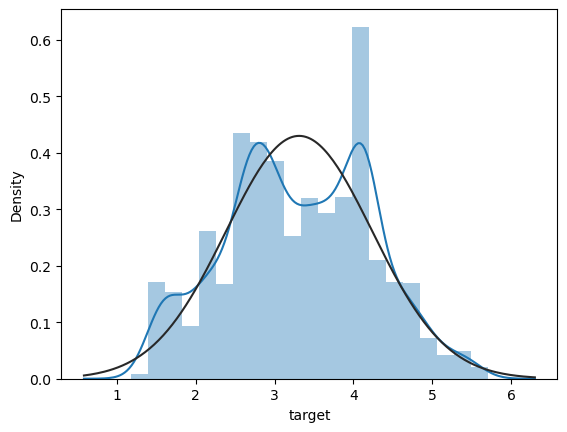

In [20]:
import seaborn as sns
from scipy.stats import norm

df["target"] = values
fig = sns.distplot(df["target"], fit=norm)

In [25]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
# GCN 모델 정의 -> 이 모델은 총 3개 GCN layer와 하나의 linear layer로 구성됨
# regression model이기 때문에 loss function은 mse 사용

class GCN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h*4)
        self.gcn2 = GCNConv(dim_h*4, dim_h*2)
        self.gcn3 = GCNConv(dim_h*2, dim_h)
        self.linear = torch.nn.Linear(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn2(h, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn3(h, edge_index)
        h = torch.relu(h)
        h = self.linear(h)
        return h

    def fit(self, data, epochs):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.02, weight_decay=5e-4)
        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            # squeeze() : 차원 축호 방법 중 하나
            loss = F.mse_loss(out.squeeze()[data.train_mask],data.y[data.train_mask].float())
            loss.backward()
            optimizer.step()
            if epoch % 20 == 0:
                val_loss = F.mse_loss(out.squeeze()[data.val_mask],data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.5f} | Val Loss: {val_loss:.5f}")

    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        return F.mse_loss(out.squeeze()[data.test_mask], data.y[data.test_mask].float())

gcn = GCN(dataset.num_features, 128, 1)
print(gcn)

gcn.fit(data, epochs=200)

loss = gcn.test(data)
print(f"\nGCN test loss: {loss:.5f}\n")

GCN(
  (gcn1): GCNConv(2325, 512)
  (gcn2): GCNConv(512, 256)
  (gcn3): GCNConv(256, 128)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)
Epoch   0 | Train Loss: 13.38260 | Val Loss: 12.62916
Epoch  20 | Train Loss: 12.09745 | Val Loss: 11.46108
Epoch  40 | Train Loss: 10.64971 | Val Loss: 10.05778
Epoch  60 | Train Loss: 9.09415 | Val Loss: 8.55262
Epoch  80 | Train Loss: 7.63892 | Val Loss: 7.14913
Epoch 100 | Train Loss: 6.34603 | Val Loss: 5.90700
Epoch 120 | Train Loss: 3.94621 | Val Loss: 3.85920
Epoch 140 | Train Loss: 2.11695 | Val Loss: 2.13900
Epoch 160 | Train Loss: 0.78195 | Val Loss: 0.85456
Epoch 180 | Train Loss: 0.72824 | Val Loss: 0.83768
Epoch 200 | Train Loss: 0.69411 | Val Loss: 0.79775

GCN test loss: 0.79844



In [26]:
# 학습이 완료된 gcn 모델을 사용하여 테스트 데이터의 예측값을 생성
# MSE, RMSE, MAE 계산
# MSE 값이 작을수록, RMSE 값이 작을수록, MAE 값이 작을수록 좋은 모델
# MSE 값이 작으면 : 모델의 오차가 적음을 뜻함
# RMSE 값이 작으면 : 모델의 예측이 실제값과 가까운 경향을 의미
# MAE 값이 작으면 : 모델이 평균적으로 더 정확한 예측을 수행함을 의미 

from sklearn.metrics import mean_squared_error, mean_absolute_error

out = gcn(data.x, data.edge_index)
y_pred = out.squeeze()[data.test_mask].detach().numpy()
mse = mean_squared_error(data.y[data.test_mask], y_pred)
mae = mean_absolute_error(data.y[data.test_mask], y_pred)

print(f"MSE = {mse:.4f} | RMSE = {np.sqrt(mse):.4f} | MAE = {mae:.4f}")

MSE = 0.7984 | RMSE = 0.8936 | MAE = 0.7445


[Text(0.5, 0, 'Ground truth'), Text(0, 0.5, 'Predicted values')]

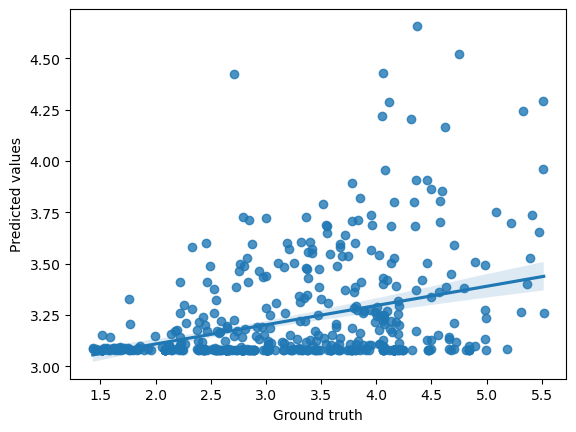

In [28]:
# 학습된 GCN 모델의 예측값과 실제값 사이 관계를 시각화
# Seaborn의 regplot()을 이용해 regression line 과 산점도를 그림
# 좋은 결과라면, 점들이 회귀선 주변에 밀접하게 나타남.
fig = sns.regplot(x=data.y[data.test_mask].numpy(), y=y_pred)
fig.set(xlabel="Ground truth", ylabel="Predicted values")

## GraphSAGE

 - 기존의 GNN 모델들이 모든 노드의 정보를 한 번에 처리하는 것과 달리,
 - GraphSAGE는 샘플링 기법을 통해 노드의 이웃을 부분적으로 선택, 이를 통해 계산 효율성을 높힘
 - 이 모델은 Node Embedding을 생성하는 데 유용. 그래프 구조를 보존하면서 확장성이 뛰어남
 - SAGE = SAmple and aggreGatE

1. 이웃 샘플링 (Neighborhood Sampling)
 - 각 노드 v에 대해 고정된 크기의 이웃 노드 집합 N(v)를 샘플링. (대규모 그래프에서 계산 복잡도를 줄이기 위한 방법)

2. 정보 집계 (Aggregation)
 - 여러 층을 통해 노드의 임베딩은 해당 노드의 이웃 노드드르이 정보를 집계하여 업데이트 됨.

3. 집계 함수 (Aggregate Function)
 1) Mean Aggregator : 이웃 노드들의 임베딩 평균을 계산
 2) *LSTM Aggregator : 이웃 노드드르이 임베딩을 LSTM 네트워크에 입력하여 계산. 순서가 없는 그래프 데이터에 적합하도록 순열 불변(permutation invariant)하지 않으므로, 이웃 노드를 무작위 순서로 입력
 3) Pooling Aggregator : 이웃 노드들의 임베딩에 대해 요소별 최대값 또는 평균값을 계산


GraphSAGE 장점
1. 확장성 : 이웃 샘플링을 통해 대규모 그래프에 효율적
2. 유연성 : 다양한 Aggregation function을 통해 다양한 그래프 구조에 적용 가능
3. 일반화 : 학습 과정에서 보지 못한 노드(unseen nodes)에 대해서도 임베딩 생성 가능

그래프데이터에서 노드 임베딩을 생성하는 강력한 도구

In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")

In [3]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root="dataset", name="Pubmed")
data = dataset[0]

print(f"Dataset: {dataset}")
print("------------------")
print(f"Number of graphs : {len(dataset)}")
print(f"Number of nodes: {data.x.shape[0]}")
print(f"Number of unique features: {dataset.num_features}")
print(f"Number of classes : {dataset.num_classes}")

print(f"\nGraph")
print(f"--------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

Processing...


Dataset: Pubmed()
------------------
Number of graphs : 1
Number of nodes: 19717
Number of unique features: 500
Number of classes : 3

Graph
--------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


Done!


In [8]:
# mini-batch dataset 만들기

# NeighborLoader는 그래프에서 특정 노드를 중심으로 일정 개수의 이웃을 샘플링하여 미니 배치를 생성하는 기능을 함.
from torch_geometric.loader import NeighborLoader
# to_networkx는 Pytorch Geometric의 데이터 객체를 networkx 형식으로 변환하는 기능을 함.
from torch_geometric.utils import to_networkx

# neighbor sampling으로 배치 만들기
train_loader = NeighborLoader(
    data,
    num_neighbors=[5, 10],
    batch_size = 16,
    input_nodes=data.train_mask,
)

# 각 하위 그래프 print
for i, subgraph in enumerate(train_loader):
    print(f"Subgraph {i}: {subgraph}")


Subgraph 0: Data(x=[414, 500], edge_index=[2, 464], y=[414], train_mask=[414], val_mask=[414], test_mask=[414], n_id=[414], e_id=[464], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[16], batch_size=16)
Subgraph 1: Data(x=[258, 500], edge_index=[2, 306], y=[258], train_mask=[258], val_mask=[258], test_mask=[258], n_id=[258], e_id=[306], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[16], batch_size=16)
Subgraph 2: Data(x=[270, 500], edge_index=[2, 310], y=[270], train_mask=[270], val_mask=[270], test_mask=[270], n_id=[270], e_id=[310], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[16], batch_size=16)
Subgraph 3: Data(x=[191, 500], edge_index=[2, 224], y=[191], train_mask=[191], val_mask=[191], test_mask=[191], n_id=[191], e_id=[224], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[12], batch_size=12)


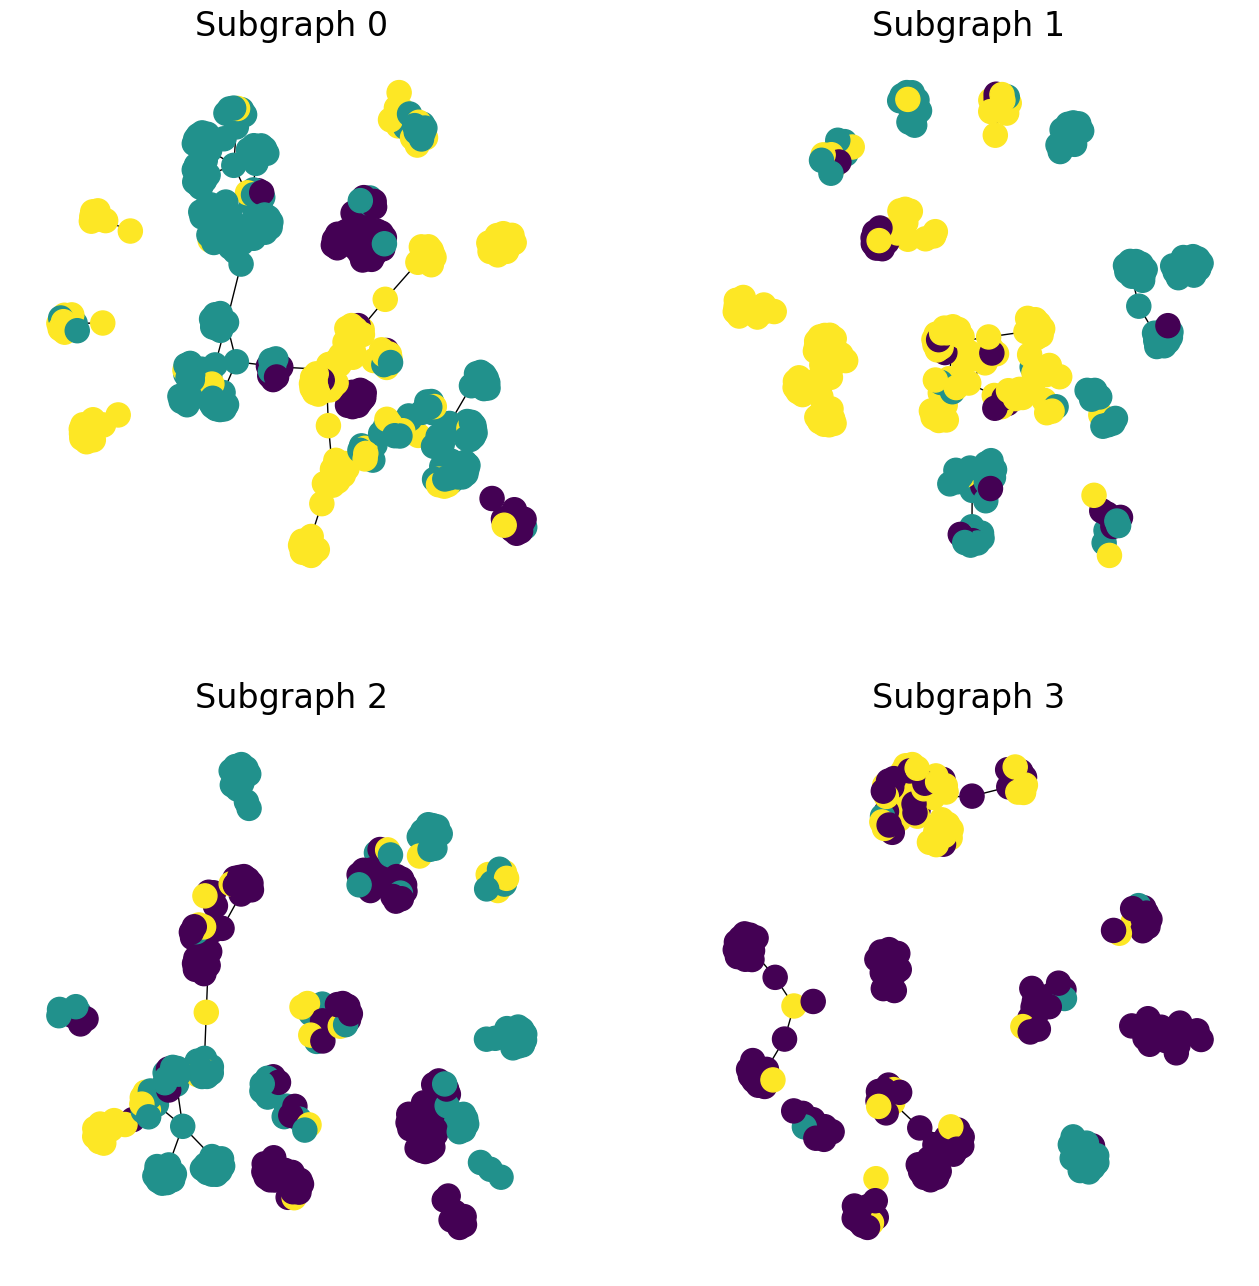

In [9]:
# Visualization
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Plot each subgraph
fig = plt.figure(figsize=(16,16))
for idx, (subdata, pos) in enumerate(zip(train_loader, [221, 222,223,224])):
    G = to_networkx(
        subdata,
        to_undirected=True
    )
    ax = fig.add_subplot(pos)
    ax.set_title(f"Subgraph {idx}", fontsize=24)
    plt.axis("off")
    nx.draw_networkx(
        G,
        pos=nx.spring_layout(G, seed=0),
        with_labels=False,
        node_color=subdata.y
    )
plt.show()
